# Classificacao de Diabetes - Aula Completa

Dataset: Pima Indians Diabetes Database  
Objetivo: prever se um paciente tem diabetes (Outcome = 1) ou nao (Outcome = 0).

Etapas desta aula:
1. Importacao das bibliotecas
2. Carregamento dos dados
3. Analise Exploratoria de Dados (EDA)
4. Pre-processamento
5. Modelagem (Naive Bayes, Redes Neurais, XGBoost, Random Forest)
6. Avaliacao e comparacao dos modelos
7. Interpretabilidade com SHAP e LIME
8. Salvamento do melhor modelo
9. Predicao com novos dados

## 1. Importacao das Bibliotecas

Importamos todas as bibliotecas necessarias de uma vez para manter o codigo organizado.  
- **pandas / numpy**: manipulacao de dados  
- **matplotlib / seaborn**: visualizacao  
- **sklearn**: pre-processamento, modelos e metricas  
- **xgboost**: modelo XGBoost  
- **shap**: explicabilidade global e local  
- **lime**: explicabilidade local por amostra

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento dos Dados

Carregamos o arquivo CSV e verificamos as primeiras linhas para entender a estrutura do dataset.

**Colunas do dataset:**
| Coluna | Descricao |
|---|---|
| Pregnancies | Numero de gestacoes |
| Glucose | Concentracao de glicose no plasma |
| BloodPressure | Pressao sanguinea diastolica (mm Hg) |
| SkinThickness | Espessura da dobra cutanea do triceps (mm) |
| Insulin | Insulina serica em 2 horas |
| BMI | Indice de massa corporal |
| DiabetesPedigreeFunction | Funcao historico familiar de diabetes |
| Age | Idade |
| Outcome | 1 = diabetico, 0 = nao diabetico (variavel alvo) |

In [3]:
df = pd.read_csv('../dataset/diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## 3. Analise Exploratoria de Dados (EDA)

### 3.1 Informacoes gerais e tipos de dados

Verificamos os tipos de cada coluna e se ha valores ausentes.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 3.2 Verificacao de valores nulos

Verificamos se ha valores nulos (NaN) no dataset.  
Neste dataset o problema e mais sutil: algumas colunas como Glucose, BMI e BloodPressure nao podem ser zero biologicamente, portanto zeros representam dados ausentes.

In [8]:
# Verificar valores nulos reais (NaN)
print('Valores nulos por coluna:')
print(df.isnull().sum())

Valores nulos por coluna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# Verificar zeros em colunas que nao deveriam ter zero
colunas_sem_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nQuantidade de zeros por coluna (possiveis dados ausentes):')
for col in colunas_sem_zero:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)')


Quantidade de zeros por coluna (possiveis dados ausentes):
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


### 3.3 Verificacao de linhas duplicadas

Linhas duplicadas podem distorcer o treinamento do modelo.

In [10]:
duplicados = df.duplicated().sum()
print(f'Linhas duplicadas: {duplicados}')

if duplicados > 0:
    df = df.drop_duplicates()
    print('Duplicatas removidas.')

Linhas duplicadas: 0


### 3.4 Distribuicao da variavel alvo

Verificamos se o dataset esta balanceado entre as classes 0 e 1.

Outcome
0    500
1    268
Name: count, dtype: int64

Proporcao:
Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


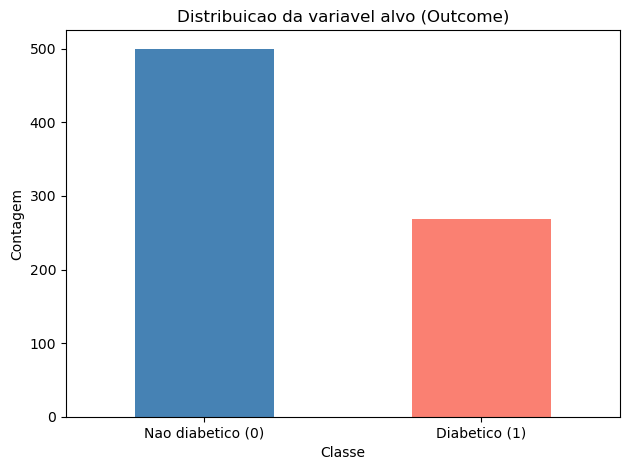

In [11]:
print(df['Outcome'].value_counts())
print('\nProporcao:')
print(df['Outcome'].value_counts(normalize=True).round(2))

df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribuicao da variavel alvo (Outcome)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Nao diabetico (0)', 'Diabetico (1)'], rotation=0)
plt.tight_layout()
plt.show()

### 3.5 Distribuicao das features

Histogramas de todas as variaveis numericas para entender a distribuicao de cada uma.

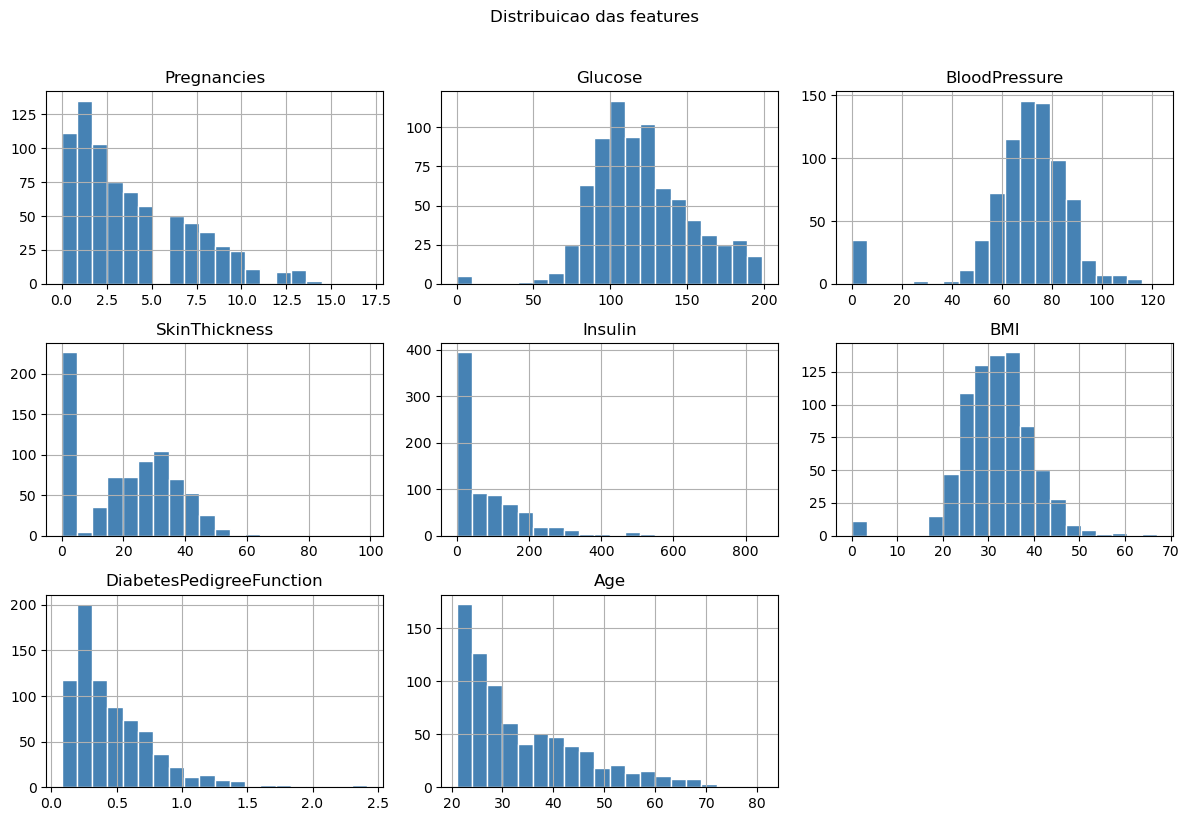

In [12]:
df.drop(columns='Outcome').hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuicao das features', y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Matriz de correlacao

A correlacao mede a relacao linear entre as variaveis. Valores proximos de 1 ou -1 indicam forte correlacao.

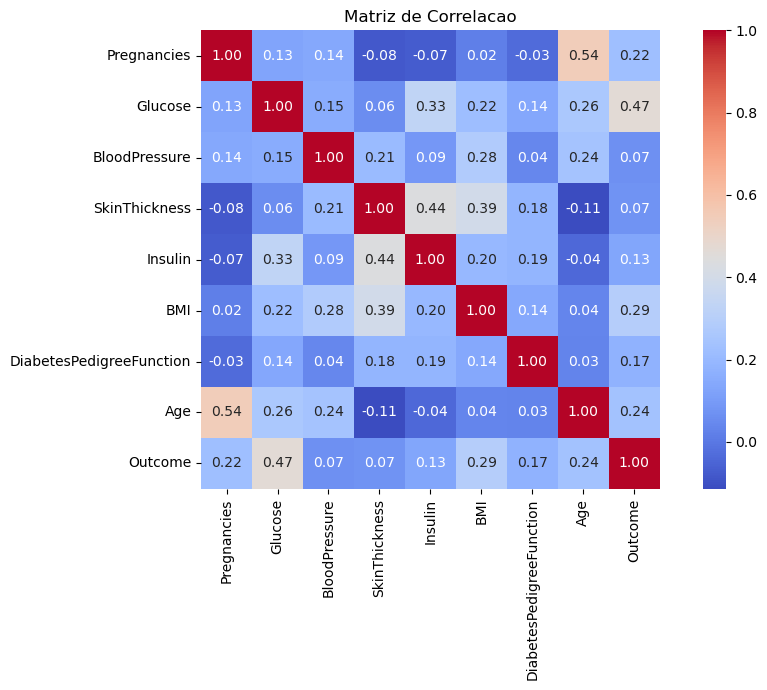

In [13]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlacao')
plt.tight_layout()
plt.show()

## 4. Pre-processamento

Etapas:
1. Substituir zeros invalidos pela mediana da coluna
2. Separar features (X) e variavel alvo (y)
3. Dividir em treino e teste
4. Normalizar as features com StandardScaler

**Por que normalizar?** Algoritmos como redes neurais e SVM sao sensiveis a escala das variaveis. Normalizar garante que todas as colunas contribuam igualmente.

In [14]:
# Substituir zeros invalidos pela mediana da coluna
colunas_sem_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in colunas_sem_zero:
    mediana = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, mediana)

print('Zeros substituidos pela mediana.')

# Separar features e variavel alvo
X = df.drop(columns='Outcome')
y = df['Outcome']

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Normalizar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Zeros substituidos pela mediana.
Treino: 537 amostras | Teste: 231 amostras


## 5. Modelagem

Vamos treinar 4 modelos de classificacao e comparar o desempenho de cada um.

Uma funcao auxiliar sera usada para imprimir as metricas de forma padronizada.

In [15]:
# Dicionario para guardar os resultados de cada modelo
resultados = {}

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1])
    resultados[nome] = {'Acuracia': round(acc, 4), 'AUC-ROC': round(auc, 4)}
    print(f'\n--- {nome} ---')
    print(f'Acuracia: {acc:.4f} | AUC-ROC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Nao Diabetico', 'Diabetico']))
    # Matriz de confusao
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de Confusao - {nome}')
    plt.tight_layout()
    plt.show()
    return modelo

### 5.1 Naive Bayes

Assume independencia entre as features e usa o Teorema de Bayes para calcular a probabilidade de cada classe.  
E rapido e funciona bem com dados numericos continuos (GaussianNB).


--- Naive Bayes ---
Acuracia: 0.7273 | AUC-ROC: 0.8040
               precision    recall  f1-score   support

Nao Diabetico       0.78      0.81      0.79       150
    Diabetico       0.62      0.58      0.60        81

     accuracy                           0.73       231
    macro avg       0.70      0.69      0.70       231
 weighted avg       0.72      0.73      0.73       231



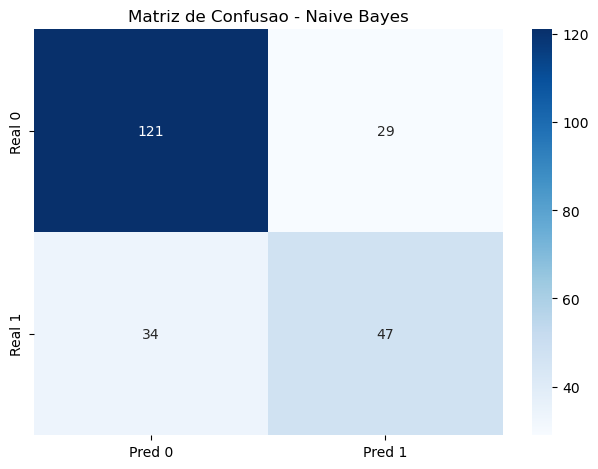

In [16]:
nb = avaliar_modelo('Naive Bayes', GaussianNB(),
                    X_train_sc, X_test_sc, y_train, y_test)

### 5.2 Rede Neural (MLP)

Uma rede neural do tipo MLP (Multi-Layer Perceptron) aprende representacoes nao lineares dos dados.  
Parametros usados: 2 camadas ocultas com 64 e 32 neuronios, funcao de ativacao ReLU.


--- Rede Neural MLP ---
Acuracia: 0.7446 | AUC-ROC: 0.7878
               precision    recall  f1-score   support

Nao Diabetico       0.80      0.81      0.81       150
    Diabetico       0.64      0.62      0.63        81

     accuracy                           0.74       231
    macro avg       0.72      0.72      0.72       231
 weighted avg       0.74      0.74      0.74       231



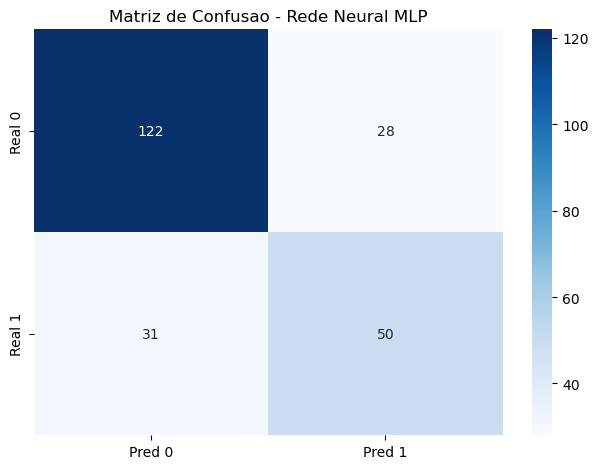

In [18]:
mlp = avaliar_modelo('Rede Neural MLP',
                     MLPClassifier(hidden_layer_sizes=(64, 32),
                                   activation='relu',
                                   max_iter=700,
                                   random_state=42),
                     X_train_sc, X_test_sc, y_train, y_test)

### 5.3 XGBoost

XGBoost (Extreme Gradient Boosting) constroi arvores de decisao sequencialmente, onde cada arvore corrige os erros da anterior.  
E um dos algoritmos mais usados em competicoes de machine learning.


--- XGBoost ---
Acuracia: 0.7446 | AUC-ROC: 0.7884
               precision    recall  f1-score   support

Nao Diabetico       0.79      0.82      0.81       150
    Diabetico       0.64      0.60      0.62        81

     accuracy                           0.74       231
    macro avg       0.72      0.71      0.72       231
 weighted avg       0.74      0.74      0.74       231



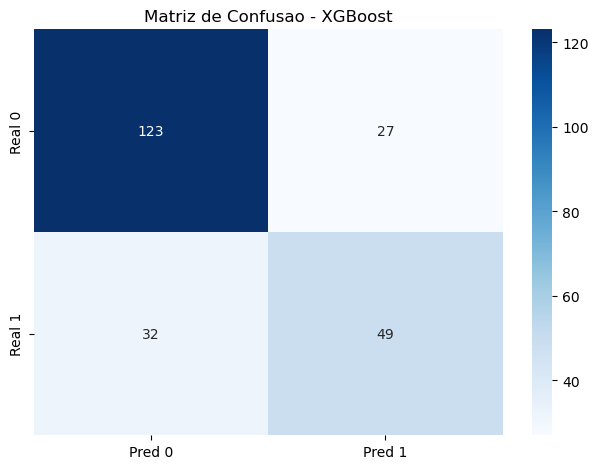

In [49]:
xgb = avaliar_modelo('XGBoost',
                     XGBClassifier(n_estimators=1200,
                                   max_depth=5,
                                   learning_rate=0.07,
                                   use_label_encoder=False,
                                   eval_metric='logloss',
                                   random_state=42),
                     X_train, X_test, y_train, y_test)

 Real  Predito  Prob_Nao_Diabetico  Prob_Diabetico     Resultado  Acertou
    1        0               1.000           0.000 Nao Diabetico    False
    1        0               0.810           0.190 Nao Diabetico    False
    1        1               0.011           0.989     Diabetico     True
    1        1               0.302           0.698     Diabetico     True
    1        1               0.452           0.548     Diabetico     True
    0        0               0.996           0.004 Nao Diabetico     True
    0        1               0.007           0.993     Diabetico    False
    0        0               0.992           0.008 Nao Diabetico     True
    0        0               1.000           0.000 Nao Diabetico     True
    0        1               0.387           0.613     Diabetico    False


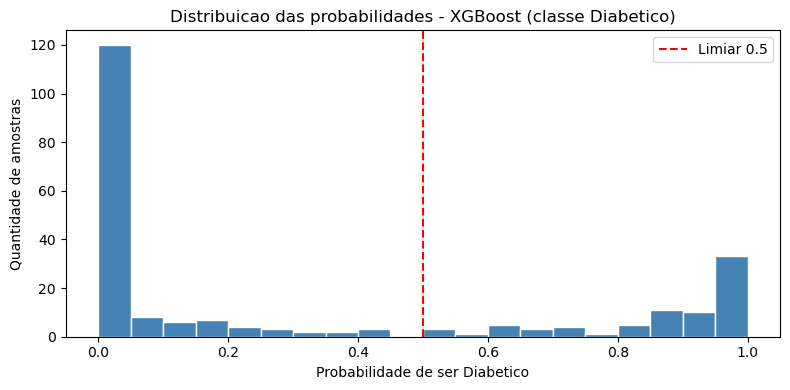

In [45]:
# Probabilidades do XGBoost para as primeiras 10 amostras do teste
probas_xgb = xgb.predict_proba(X_test)

df_probas = pd.DataFrame({
    'Real':                y_test.values[:10],
    'Predito':             xgb.predict(X_test)[:10],
    'Prob_Nao_Diabetico':  probas_xgb[:10, 0].round(3),
    'Prob_Diabetico':      probas_xgb[:10, 1].round(3),
})
df_probas['Resultado'] = df_probas['Predito'].map({0: 'Nao Diabetico', 1: 'Diabetico'})
df_probas['Acertou']   = df_probas['Real'] == df_probas['Predito']

print(df_probas.to_string(index=False))

# Distribuicao das probabilidades previstas para a classe Diabetico
plt.figure(figsize=(8, 4))
plt.hist(probas_xgb[:, 1], bins=20, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Limiar 0.5')
plt.title('Distribuicao das probabilidades - XGBoost (classe Diabetico)')
plt.xlabel('Probabilidade de ser Diabetico')
plt.ylabel('Quantidade de amostras')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Arvore de Decisao

A Arvore de Decisao divide o espaco de features em regioes usando regras de corte (if/else).  
E um modelo interpretavel: e possivel visualizar cada regra aprendida.  
`max_depth` limita a profundidade da arvore para evitar overfitting.


--- Arvore de Decisao ---
Acuracia: 0.7316 | AUC-ROC: 0.7488
               precision    recall  f1-score   support

Nao Diabetico       0.78      0.83      0.80       150
    Diabetico       0.63      0.56      0.59        81

     accuracy                           0.73       231
    macro avg       0.70      0.69      0.70       231
 weighted avg       0.73      0.73      0.73       231



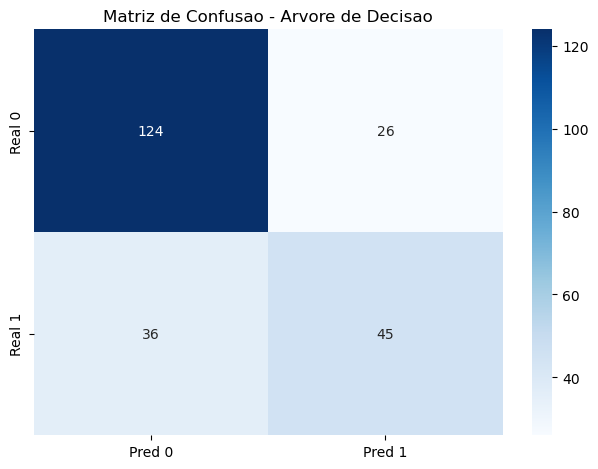

In [60]:
dt = avaliar_modelo('Arvore de Decisao',
                    DecisionTreeClassifier(max_depth=5,
                                           random_state=42),
                    X_train, X_test, y_train, y_test)

### Visualizacao da Arvore de Decisao

- Cada **no interno** mostra: a regra de corte, o numero de amostras e a classe majoritaria  
- Cada **folha** mostra a classe prevista  
- A cor indica a classe dominante: azul = Nao Diabetico, laranja = Diabetico  
- Quanto mais escura a cor, mais pura e o no (menos mistura entre classes)  
- `export_text` mostra o mesmo em formato de texto, facil de copiar para slides

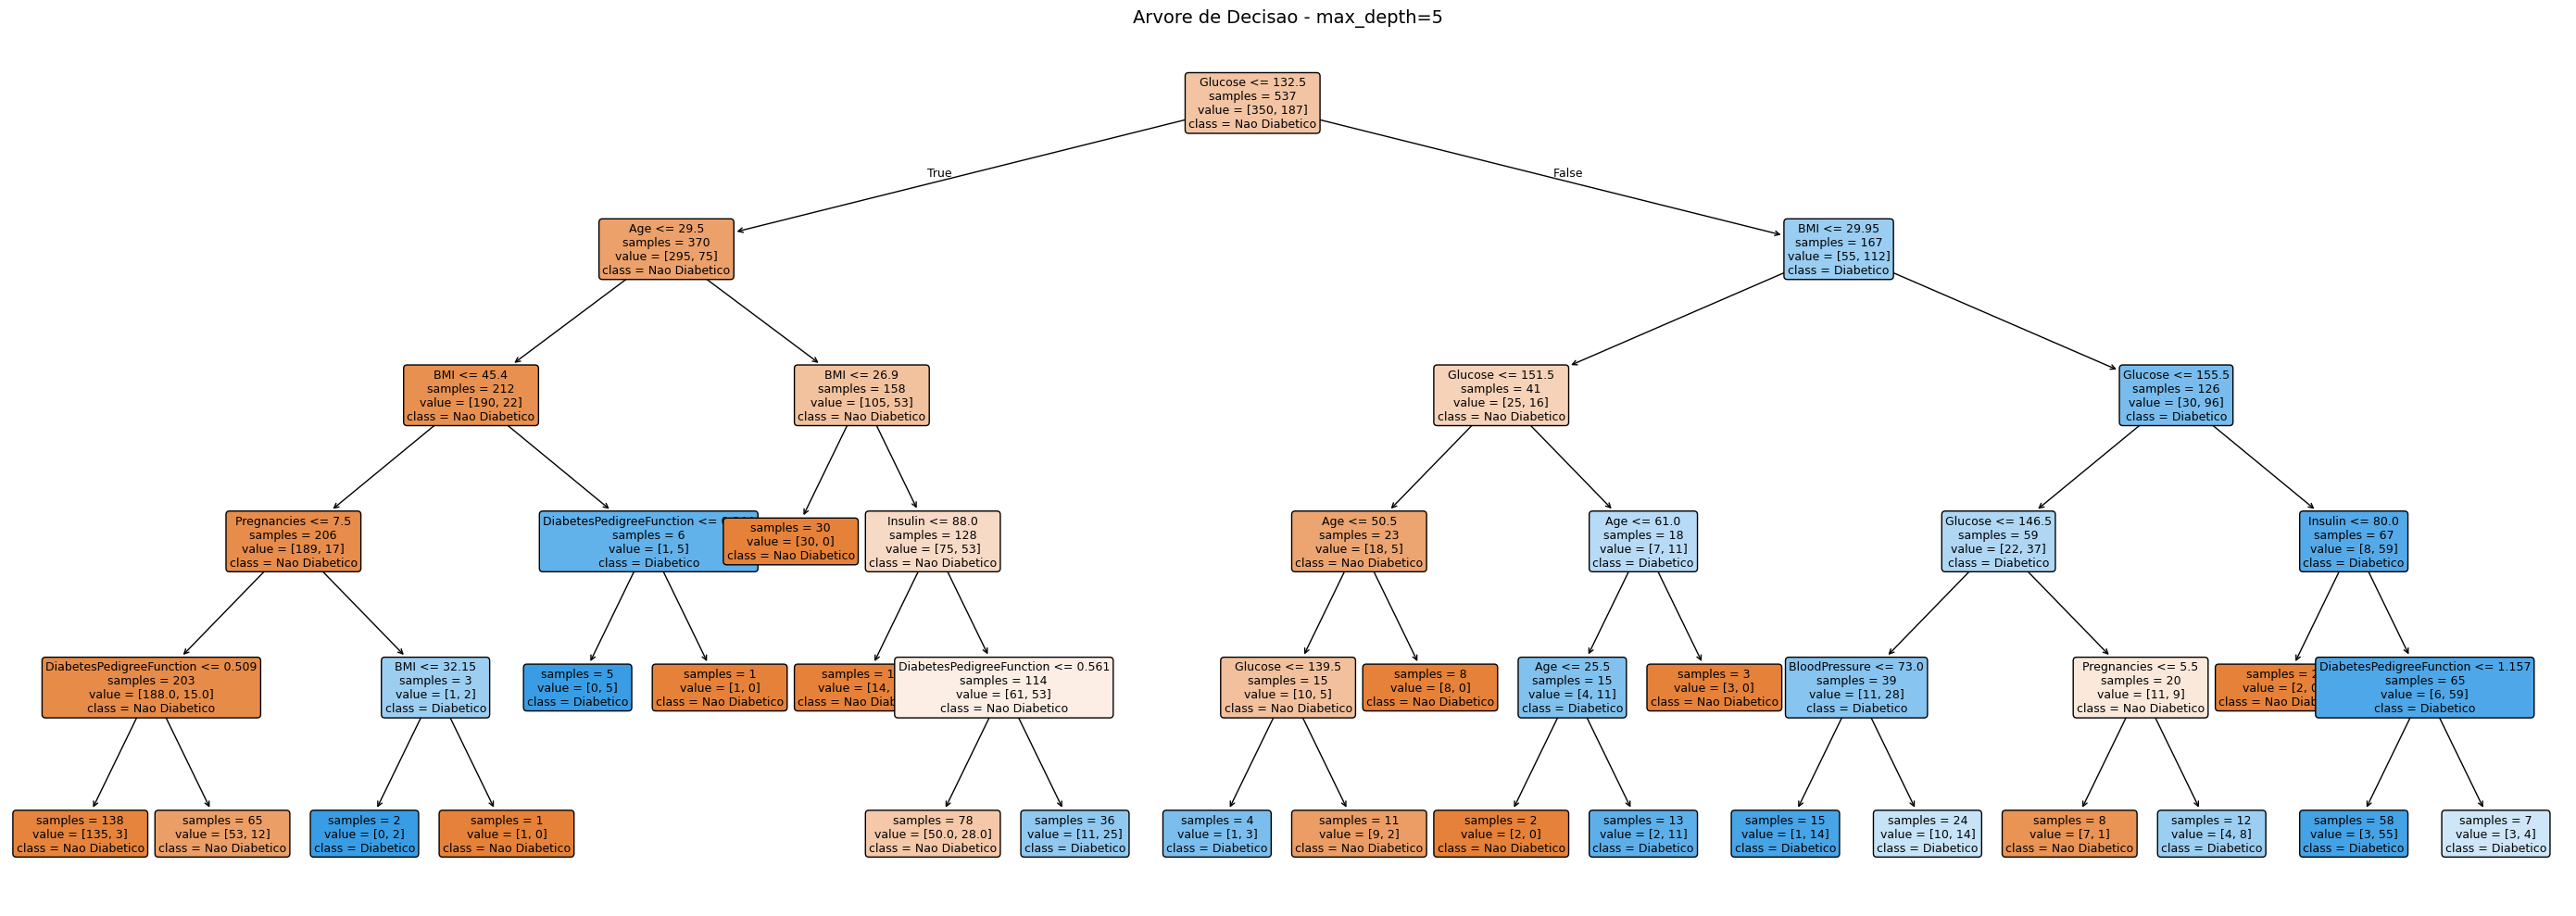

|--- Glucose <= 132.50
|   |--- Age <= 29.50
|   |   |--- BMI <= 45.40
|   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.51
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DiabetesPedigreeFunction >  0.51
|   |   |   |   |   |--- class: 0
|   |   |   |--- Pregnancies >  7.50
|   |   |   |   |--- BMI <= 32.15
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- BMI >  32.15
|   |   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- DiabetesPedigreeFunction <= 0.84
|   |   |   |   |--- class: 1
|   |   |   |--- DiabetesPedigreeFunction >  0.84
|   |   |   |   |--- class: 0
|   |--- Age >  29.50
|   |   |--- BMI <= 26.90
|   |   |   |--- class: 0
|   |   |--- BMI >  26.90
|   |   |   |--- Insulin <= 88.00
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  88.00
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.56
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DiabetesPedigreeFunction >  0.56
|   |   |   |   |

In [58]:
from sklearn.tree import plot_tree, export_text

# Visualizacao grafica da arvore
plt.figure(figsize=(28, 10))
plot_tree(
    dt,
    feature_names=list(X_train.columns),
    class_names=['Nao Diabetico', 'Diabetico'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    proportion=False
)
plt.title('Arvore de Decisao - max_depth=5', fontsize=14)
plt.tight_layout()
plt.show()

# Representacao textual (util para aula - mais facil de ler no notebook)
print(export_text(dt, feature_names=list(X_train.columns)))

### 5.5 Random Forest

Random Forest cria multiplas arvores de decisao com subconjuntos aleatorios dos dados e das features.  
A predicao final e a votacao majoritaria entre todas as arvores (ensemble).


--- Random Forest ---
Acuracia: 0.7489 | AUC-ROC: 0.8285
               precision    recall  f1-score   support

Nao Diabetico       0.77      0.87      0.82       150
    Diabetico       0.68      0.53      0.60        81

     accuracy                           0.75       231
    macro avg       0.73      0.70      0.71       231
 weighted avg       0.74      0.75      0.74       231



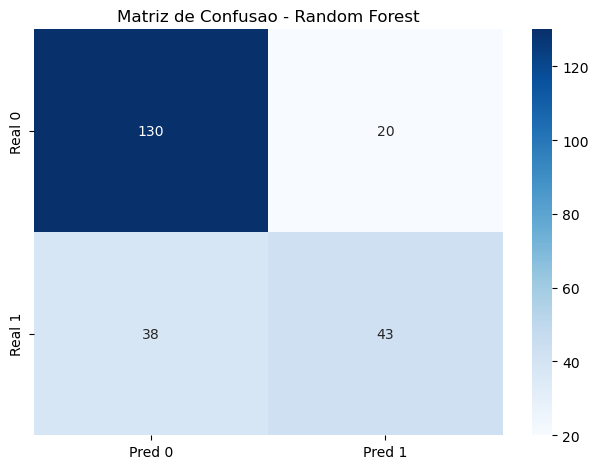

In [65]:
rf = avaliar_modelo('Random Forest',
                    RandomForestClassifier(n_estimators=1000,
                                           max_depth=6,
                                           random_state=42),
                    X_train, X_test, y_train, y_test)

## 6. Comparacao dos Modelos

Resumo das metricas de todos os modelos treinados para facilitar a escolha do melhor.

In [66]:
df_resultados = pd.DataFrame(resultados).T.sort_values('AUC-ROC', ascending=False)
print(df_resultados)

# Identificar o melhor modelo pelo AUC-ROC
melhor_nome = df_resultados['AUC-ROC'].idxmax()
print(f'\nMelhor modelo: {melhor_nome}')

# Mapear nome para objeto do modelo
modelos = {
    'Naive Bayes':       nb,
    'Rede Neural MLP':  mlp,
    'XGBoost':           xgb,
    'Arvore de Decisao': dt,
    'Random Forest':     rf,
}
melhor_modelo = modelos[melhor_nome]

                   Acuracia  AUC-ROC
Random Forest        0.7489   0.8285
Naive Bayes          0.7273   0.8040
XGBoost              0.7446   0.7884
Rede Neural MLP      0.7446   0.7878
Arvore de Decisao    0.7316   0.7488

Melhor modelo: Random Forest


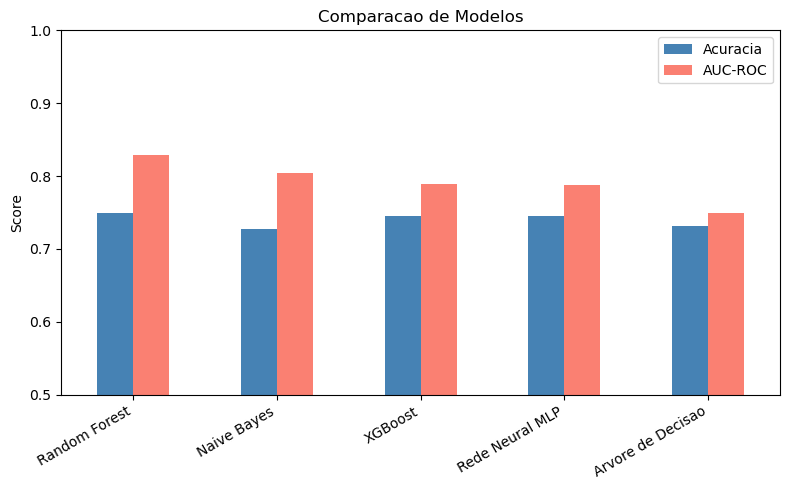

In [67]:
ax = df_resultados.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'salmon'])
plt.title('Comparacao de Modelos')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6.1 Otimizacao de Hiperparametros - GridSearchCV

Usamos **GridSearchCV** com validacao cruzada (5 folds) para encontrar os melhores hiperparametros para Random Forest e XGBoost.  
A metrica principal e o **AUC-ROC**, mais adequada para datasets desbalanceados como este.


In [68]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ──────────────────────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [200, 500, 1000],
    'max_depth':    [4, 6, 8],
    'min_samples_split': [2, 5],
}

print('Iniciando GridSearchCV - Random Forest...')
t0 = time.time()
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)
print(f'Concluido em {time.time()-t0:.1f}s')
print(f'Melhores parametros RF : {gs_rf.best_params_}')
print(f'Melhor AUC-ROC (CV)    : {gs_rf.best_score_:.4f}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators':  [300, 600, 1000],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

print('\nIniciando GridSearchCV - XGBoost...')
t0 = time.time()
gs_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid_xgb,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
gs_xgb.fit(X_train, y_train)
print(f'Concluido em {time.time()-t0:.1f}s')
print(f'Melhores parametros XGB: {gs_xgb.best_params_}')
print(f'Melhor AUC-ROC (CV)    : {gs_xgb.best_score_:.4f}')


Iniciando GridSearchCV - Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Concluido em 30.3s
Melhores parametros RF : {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200}
Melhor AUC-ROC (CV)    : 0.8363

Iniciando GridSearchCV - XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Concluido em 7.4s
Melhores parametros XGB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Melhor AUC-ROC (CV)    : 0.8064



--- Random Forest (GridSearch) ---
Acuracia: 0.7532 | AUC-ROC: 0.8277
               precision    recall  f1-score   support

Nao Diabetico       0.78      0.87      0.82       150
    Diabetico       0.69      0.54      0.61        81

     accuracy                           0.75       231
    macro avg       0.73      0.70      0.71       231
 weighted avg       0.75      0.75      0.75       231


--- XGBoost (GridSearch) ---
Acuracia: 0.7576 | AUC-ROC: 0.8288
               precision    recall  f1-score   support

Nao Diabetico       0.79      0.86      0.82       150
    Diabetico       0.69      0.57      0.62        81

     accuracy                           0.76       231
    macro avg       0.74      0.71      0.72       231
 weighted avg       0.75      0.76      0.75       231


Comparativo Original vs. Otimizado:
        Modelo  AUC-ROC (teste)  AUC-ROC (CV)
   RF Original           0.8285           NaN
 RF GridSearch           0.8277        0.8363
  XGB Original         

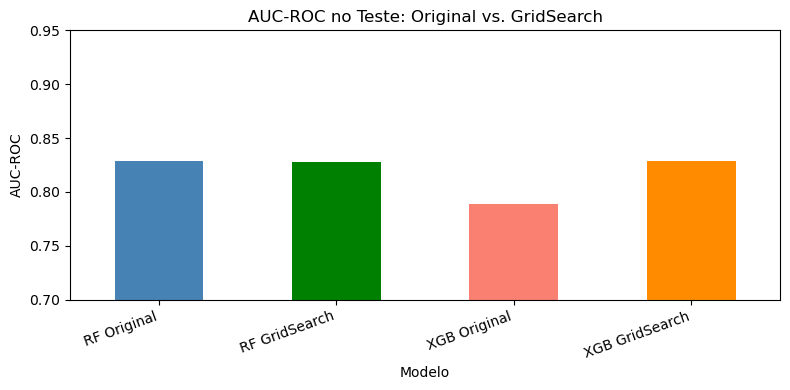

In [69]:
# Avaliacao dos modelos otimizados no conjunto de teste
rf_best  = gs_rf.best_estimator_
xgb_best = gs_xgb.best_estimator_

for nome, modelo in [('Random Forest (GridSearch)', rf_best),
                     ('XGBoost (GridSearch)',        xgb_best)]:
    y_pred = modelo.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    print(f'\n--- {nome} ---')
    print(f'Acuracia: {acc:.4f} | AUC-ROC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Nao Diabetico', 'Diabetico']))

# Comparativo final: modelos originais vs. otimizados
df_gs = pd.DataFrame({
    'Modelo': ['RF Original', 'RF GridSearch', 'XGB Original', 'XGB GridSearch'],
    'AUC-ROC (teste)': [
        resultados['Random Forest']['AUC-ROC'],
        round(roc_auc_score(y_test, rf_best.predict_proba(X_test)[:, 1]), 4),
        resultados['XGBoost']['AUC-ROC'],
        round(roc_auc_score(y_test, xgb_best.predict_proba(X_test)[:, 1]), 4),
    ],
    'AUC-ROC (CV)': [
        None, round(gs_rf.best_score_,  4),
        None, round(gs_xgb.best_score_, 4),
    ]
})
print('\nComparativo Original vs. Otimizado:')
print(df_gs.to_string(index=False))

# Grafico
ax = df_gs.plot(x='Modelo', y='AUC-ROC (teste)', kind='bar',
                figsize=(8, 4), color=['steelblue', 'green', 'salmon', 'darkorange'],
                legend=False)
plt.title('AUC-ROC no Teste: Original vs. GridSearch')
plt.ylabel('AUC-ROC')
plt.ylim(0.70, 0.95)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 7. Interpretabilidade com SHAP

**SHAP (SHapley Additive exPlanations)** calcula a contribuicao de cada feature para cada predicao.  

- `summary_plot`: mostra a importancia global de todas as features  
- Cada ponto representa uma amostra  
- Cor vermelha = valor alto da feature, azul = valor baixo  
- Posicao no eixo X indica se a feature empurra a predicao para 1 (direita) ou 0 (esquerda)

Usaremos o melhor modelo. Se for RandomForest ou XGBoost, usamos `TreeExplainer` (mais rapido).  
Para outros modelos, usamos `KernelExplainer`.

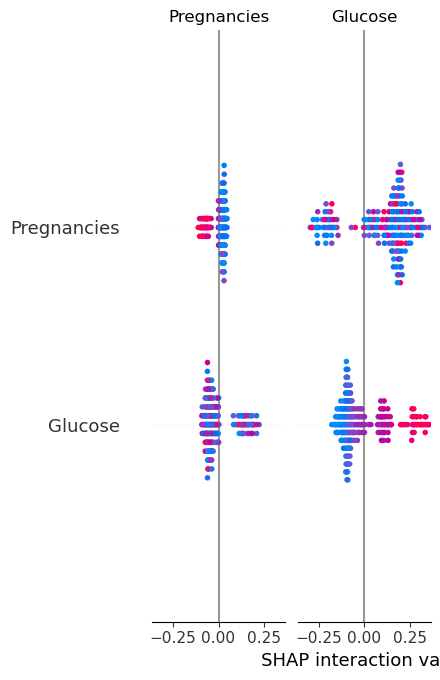

In [71]:
feature_names = list(X.columns)

# Escolher o explainer adequado
if melhor_nome in ('XGBoost', 'Random Forest'):
    explainer = shap.TreeExplainer(melhor_modelo)
    shap_values = explainer.shap_values(X_test)
    # Random Forest retorna lista com shap por classe; pegar classe 1
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values
else:
    background = shap.sample(pd.DataFrame(X_train, columns=feature_names), 100)
    explainer = shap.KernelExplainer(melhor_modelo.predict_proba, background)
    shap_values = explainer.shap_values(
        pd.DataFrame(X_test[:50], columns=feature_names)
    )
    sv = shap_values[1]

# Summary plot
shap.summary_plot(sv, pd.DataFrame(X_test, columns=feature_names), show=True)

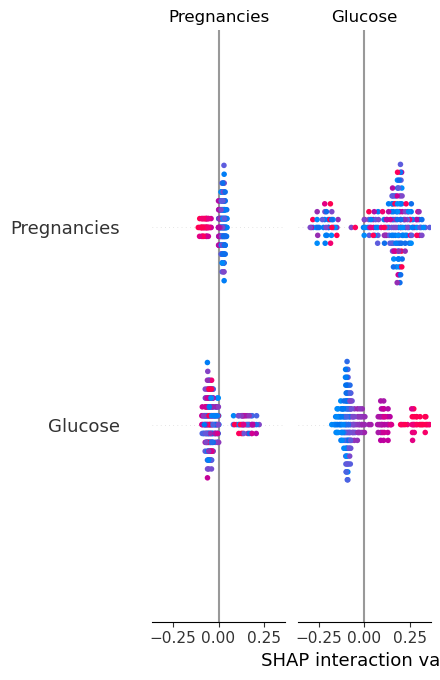

In [72]:
# SHAP bar plot: importancia media absoluta de cada feature
shap.summary_plot(sv, pd.DataFrame(X_test, columns=feature_names),
                  plot_type='bar', show=True)

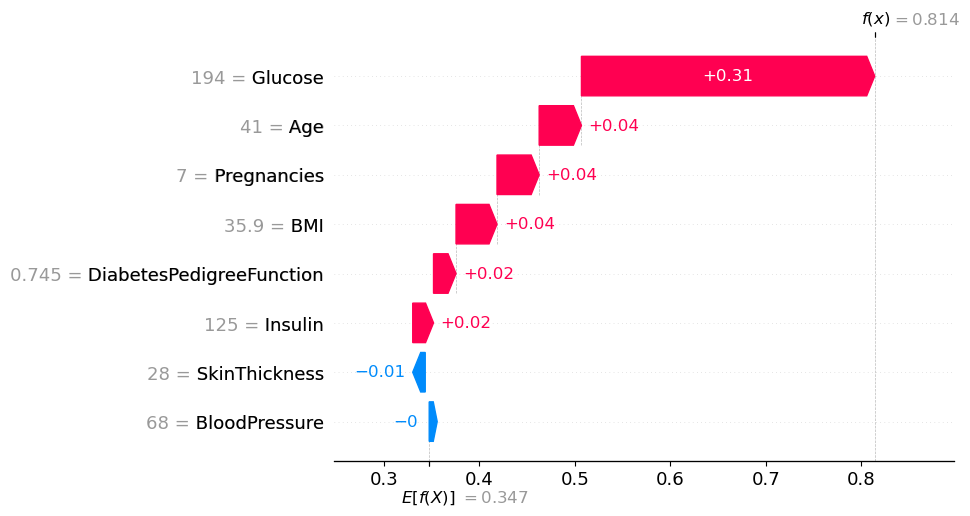

In [82]:
# SHAP waterfall para uma unica amostra (amostra 0 do conjunto de teste)
idx = 15

# sv pode ser 3D (n_amostras, n_features, n_classes) em versoes recentes do SHAP
# para Random Forest; extrair a fatia de classe 1 quando necessario
sv_sample = sv[idx] if sv.ndim == 2 else sv[idx, :, 1]

# base_values: escalar para modelos de saida unica, array para multiclasse
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = float(np.asarray(explainer.expected_value).flat[1])
else:
    base_val = float(explainer.expected_value)

shap_exp = shap.Explanation(
    values=sv_sample,
    base_values=base_val,
    data=X_test.iloc[idx].values,
    feature_names=feature_names
)
shap.plots.waterfall(shap_exp, show=True)


## 8. Interpretabilidade com LIME

**LIME (Local Interpretable Model-agnostic Explanations)** explica predicoes individuais criando um modelo simples (linear) ao redor de cada amostra.  

- Util para entender por que o modelo tomou uma decisao especifica  
- Funciona com qualquer modelo (model-agnostic)  
- O grafico mostra quais features contribuiram para a classe predita e com qual peso

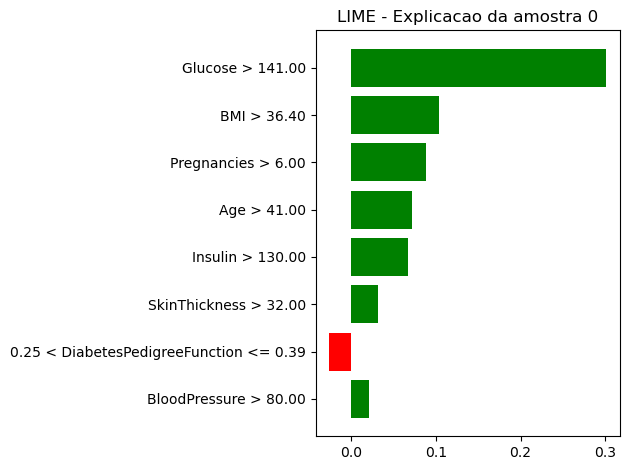

In [85]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Nao Diabetico', 'Diabetico'],
    mode='classification'
)

# Explicar a mesma amostra usada no SHAP (amostra 0 do teste)
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[2].values,
    predict_fn=melhor_modelo.predict_proba,
    num_features=8
)

exp.as_pyplot_figure()
plt.title('LIME - Explicacao da amostra 0')
plt.tight_layout()
plt.show()

## 9. Salvar o Melhor Modelo

Salvamos o modelo e o scaler juntos para que a predicao futura use a mesma normalizacao aplicada durante o treino.  
Usamos `joblib`, que e mais eficiente que `pickle` para objetos numpy/sklearn.

In [86]:
import os

# Criar pasta para salvar o modelo
os.makedirs('../modelos', exist_ok=True)

# Salvar modelo e scaler
joblib.dump(melhor_modelo, '../modelos/diabetes_melhor_modelo.pkl')
joblib.dump(scaler,        '../modelos/diabetes_scaler.pkl')

print(f'Modelo "{melhor_nome}" salvo em ../modelos/diabetes_melhor_modelo.pkl')
print('Scaler salvo em ../modelos/diabetes_scaler.pkl')

Modelo "Random Forest" salvo em ../modelos/diabetes_melhor_modelo.pkl
Scaler salvo em ../modelos/diabetes_scaler.pkl


## 10. Predicao com Novos Dados

Para prever novos casos, o processo e:
1. Carregar o modelo e o scaler salvos
2. Criar um DataFrame com os dados novos (mesmas colunas do treino)
3. Aplicar o scaler nos dados novos
4. Chamar `predict` e `predict_proba`

In [87]:
# Carregar modelo e scaler do disco
modelo_carregado = joblib.load('../modelos/diabetes_melhor_modelo.pkl')
scaler_carregado = joblib.load('../modelos/diabetes_scaler.pkl')

# Dados novos de exemplo (3 pacientes fictícios)
novos_dados = pd.DataFrame({
    'Pregnancies':              [2,  5,  1],
    'Glucose':                  [120, 180, 90],
    'BloodPressure':            [70,  80,  60],
    'SkinThickness':            [25,  30,  20],
    'Insulin':                  [80,  150, 70],
    'BMI':                      [28.5, 35.0, 22.0],
    'DiabetesPedigreeFunction': [0.35, 0.7, 0.2],
    'Age':                      [30,  50,  25],
})

# Aplicar o mesmo scaler do treino
#novos_sc = scaler_carregado.transform(novos_dados)
novos_sc = novos_dados.copy()

# Predicao
predicoes   = modelo_carregado.predict(novos_sc)
proba_diab  = modelo_carregado.predict_proba(novos_sc)[:, 1]

novos_dados['Predicao']          = predicoes
novos_dados['Prob_Diabetes (%)'] = (proba_diab * 100).round(1)
novos_dados['Resultado']         = novos_dados['Predicao'].map({0: 'Nao Diabetico', 1: 'Diabetico'})

print(novos_dados[['Glucose', 'BMI', 'Age', 'Predicao', 'Prob_Diabetes (%)', 'Resultado']].to_string(index=False))

 Glucose  BMI  Age  Predicao  Prob_Diabetes (%)     Resultado
     120 28.5   30         0               10.9 Nao Diabetico
     180 35.0   50         1               81.7     Diabetico
      90 22.0   25         0                1.2 Nao Diabetico


---

## Resumo da Aula

| Etapa | O que fizemos |
|---|---|
| EDA | Verificamos nulos, zeros invalidos, duplicatas, distribuicoes e correlacoes |
| Pre-processamento | Substituimos zeros pela mediana, normalizamos com StandardScaler |
| Modelagem | Treinamos Naive Bayes, MLP, XGBoost e Random Forest |
| Avaliacao | Comparamos Acuracia e AUC-ROC para escolher o melhor modelo |
| SHAP | Interpretamos importancia global e local das features |
| LIME | Explicamos uma predicao individual |
| Salvamento | Guardamos o modelo e o scaler com joblib |
| Predicao | Fizemos predicoes em novos dados carregando o modelo salvo |